<a href="https://colab.research.google.com/github/RyanO14/ENGPHYS-2NM4/blob/main/Assignments/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2



## Question 1

A nuclear fuel pellet is a cylinder, 1.5 cm in lenth and 1 cm in diameter. Assume the surface temperature is 300 C everywhere. Given temperature probe data below, determine the radial temperature profile in the middle of a nuclear fuel pellet (i.e.: T(r, z = 0.75)) using radial basis functions.


In [ ]:
import numpy as np

# 20 data points presented in columns: | x | y | z | T |, measurements in cm

data = np.array([
    [5.1690e-02, 2.3766e-01, 6.7059e-01, 5.2645e+02],
    [1.1353e-01, 9.4708e-02, 5.3856e-01, 5.5201e+02],
    [1.6676e-01, 1.4358e-01, 4.6936e-01, 5.0802e+02],
    [1.3610e-01, 3.7207e-02, 2.1694e-01, 4.3663e+02],
    [8.9225e-02, 3.7293e-01, 1.1270e+00, 3.9234e+02],
    [1.9001e-01, 3.7240e-01, 8.4774e-01, 3.8872e+02],
    [5.4849e-02, 3.5425e-01, 5.7478e-01, 4.3784e+02],
    [1.7001e-01, 2.0241e-01, 1.2960e+00, 4.0159e+02],
    [2.0606e-01, 3.1594e-01, 6.4077e-01, 4.2652e+02],
    [2.5382e-01, 2.5859e-01, 4.8610e-01, 4.2481e+02],
    [5.6038e-02, 8.2231e-02, 4.2029e-01, 5.3244e+02],
    [3.1242e-01, 8.0489e-02, 1.1530e+00, 4.2453e+02],
    [6.0186e-02, 4.4891e-01, 3.9941e-01, 3.4207e+02],
    [1.5070e-01, 3.4794e-01, 1.5595e-01, 3.4750e+02],
    [1.8215e-01, 3.4388e-01, 1.0478e+00, 3.9963e+02],
    [1.1633e-01, 4.1011e-01, 5.5001e-01, 3.7611e+02],
    [1.2377e-01, 3.3703e-01, 3.7672e-02, 3.1423e+02],
    [4.6378e-02, 3.3653e-01, 1.4434e+00, 3.2345e+02],
    [2.9063e-02, 3.2584e-02, 2.3977e-01, 4.5993e+02],
    [2.1162e-02, 3.8590e-01, 2.5905e-01, 3.6901e+02]
])

Consider what you know about this system. What extra information do you have in terms of

### a) type(s) of symmetry?

This problem can be reduced into a one-dimensional radial temperature profile at the axial midpoint. There is no angle dependance and no [radial] slope at r = 0.

### b) Boundary conditions?

The given boundary condition is a fixed temperature of 300degC at every point on the pellet's surface. It can be assumed that the interior physics is symmetric about the pellet's middle plane.

## c) Plot the best guess of the radial temperature profile

Note: RBFs will fail with a linear solver error if two data points exactly overlap.

A Gaussian RBF approach can be used and applied to the pellet's cylindrical coordinates. First (x, y, z) coordinates can be changed to (r, z) because of the radial symmetry. Points of 300degC can be placed on the outer wall as both as both end faces. Then the RBF can be fit to all points and be evaluated along z = 0.75. Before fitting, any points with identical (r, z) coordindates can be combined to prevent the solver from returning an error. A smoothing term will also help this solver return a more numerically stable result.

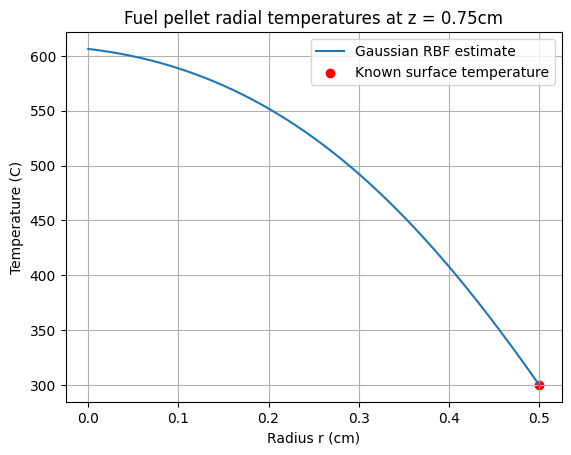

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RBFInterpolator
from scipy.spatial.distance import pdist

#Dimensions, cm
R = 0.5
L = 1.5
T_surface = 300.0

# (x, y, z) to (r, z)
r_probe = np.hypot(data[:, 0], data[:, 1])
probe_points = np.column_stack((r_probe, data[:, 2]))
probe_temperatures = data[:, 3]

#Add boundary to wall and end faces
z_wall = np.linspace(0, L, 11)
r_face = np.linspace(0, R, 6)

wall_points = np.column_stack((
    np.full_like(z_wall, R),
    z_wall
))
bottom_points = np.column_stack((
    r_face,
    np.zeros_like(r_face)
))
top_points = np.column_stack((
    r_face,
    np.full_like(r_face, L)
))

boundary_points = np.vstack((
    wall_points, bottom_points, top_points
))
boundary_temperatures = np.full(
    len(boundary_points), T_surface
)

points = np.vstack((probe_points, boundary_points))
temperatures = np.concatenate((
    probe_temperatures, boundary_temperatures
))

#Merge overlapping points, if temperatures are different, use average
unique_points, inverse = np.unique(
    points, axis=0, return_inverse=True
)
unique_temperatures = (
    np.bincount(inverse, weights=temperatures)
    / np.bincount(inverse)
)

#RBF Solver
mean_distance = pdist(unique_points).mean()
epsilon = 1 / mean_distance

rbf = RBFInterpolator(
    unique_points,
    unique_temperatures,
    kernel='gaussian',
    epsilon=epsilon,
    smoothing=1e-5
)

#Evaluate at z = 0.75
r_plot = np.linspace(0, R, 300)
midplane_points = np.column_stack((
    r_plot,
    np.full_like(r_plot, L / 2)
))
T_plot = rbf(midplane_points)

#Evaluate at z = 0.75
r_plot = np.linspace(0, R, 300)
midplane_points = np.column_stack((
    r_plot,
    np.full_like(r_plot, L / 2)
))
T_plot = rbf(midplane_points)

plt.plot(r_plot, T_plot, label="Gaussian RBF estimate")
plt.scatter([R], [T_surface], color = 'red', label = 'Known surface temperature')
plt.xlabel("Radius r (cm)")
plt.ylabel("Temperature (C)")
plt.title("Fuel pellet radial temperatures at z = 0.75cm")
plt.grid(True)
plt.legend()
plt.show()

The plotted curve is an RBF-based estimate of the temperature variation from the centreline of the fuel pellet to its outside surface at the middle height, z = 0.75cm. The temperature is expected to be highest near the center because the outside is to remain at 300C. This result is physically reasonable, as the heat generated in the pellet interior must conduct outward to the cooler fixed-temperature surface.


# Question 2

You run an experiment and obtain the following data:

| x | y1 | y2 | y3 | y4 | y5 |
|---|---|---|---| --- | --- |
| 0.00 | -29.49 | -2.14 | 15.88 | 22.69 | 28.53 |
| 1.11 | 2.83 | 18.02 | -25.45 | -32.45 | 7.50 |
| 2.22 | 1.97 | -10.49 | -0.18 | -32.10 | -40.31 |
| 3.33 | -38.09 | -46.16 | -7.87 | -33.97 | -38.39 |
| 4.44 | -3.97 | -32.22 | -33.95 | -11.07 | -32.47 |
| 5.56 | 4.45 | -10.88 | 20.43 | 6.57 | -8.49 |
| 6.67 | 50.22 | 51.29 | 80.02 | 66.15 | 84.90 |
| 7.78 | 164.11 | 190.26 | 160.94 | 182.35 | 163.18 |
| 8.89 | 331.75 | 306.51 | 278.40 | 302.13 | 335.44 |
| 10.00 | 517.06 | 483.20 | 476.73 | 512.16 | 500.64 |



In [ ]:
import numpy as np

# Define the table as a list of lists
d = np.array([
    [0.00, -29.49, -2.14, 15.88, 22.69, 28.53],
    [1.11, 2.83, 18.02, -25.45, -32.45, 7.50],
    [2.22, 1.97, -10.49, -0.18, -32.10, -40.31],
    [3.33, -38.09, -46.16, -7.87, -33.97, -38.39],
    [4.44, -3.97, -32.22, -33.95, -11.07, -32.47],
    [5.56, 4.45, -10.88, 20.43, 6.57, -8.49],
    [6.67, 50.22, 51.29, 80.02, 66.15, 84.90],
    [7.78, 164.11, 190.26, 160.94, 182.35, 163.18],
    [8.89, 331.75, 306.51, 278.40, 302.13, 335.44],
    [10.00, 517.06, 483.20, 476.73, 512.16, 500.64]
])

## a) Determine the best cubic polynomial fit to this data with the uncertainty

For each xi, the mean and standard deviation of the 5 measurements can be calculated. The mean values represent the measured trend, while the standard deviations represent the uncertainty at each xi. A cubic model can be fitted to the mean values using least squares. The fit can be weighted by the measurement uncertainty using weights wi = 1/si^2. The uncertainty bands can be shown as avg(yi) +/- si.

In [ ]:
x = data[:, 0]
y = data[:, 1]

#Mean and sample standard deviation
y_mean = np.mean(y, axis=1)
y_std = np.std(y, axis=1, ddof=1)

#Cubic weighted least-squares fit
cubic_coefficients = np.polyfit(
    x,
    y_mean,
    deg=3,
    w=1 / y_std
)

#Quadratic weighted least-squares fit
quadractic_coefficients = np.polyfit(
    x,
    y_mean,
    deg=2,
    w=1 / y_std
)

x_plot = np.linspace(x.min(), x.max(), 500)
y_cubic = np.polyval(cubic_coefficients, x_plot)
y_quadratic = np.polyval(quadractic_coefficients, x_plot)

plt.figure(figsize=(8, 5))

plt.errorbar(
    x,
    y_mean,
    yerr=y_std,
    fmt="o",
    capsize=4,
    label="Mean measurement +/- 1 standard deviation"
)

plt.plot(
    x_plot,
    y_cubic,
    label="Weighted cubic fit",
    linewidth=2
)

plt.plot(
    x_plot,
    y_quadratic,
    "--",
    label="Weighted quadractic fit",
    linewidth=2
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial fits to experimental data")
plt.grid(True)
plt.legend()
plt.show()

## b) Your manager thinks this should be a quadratic. Which do you think it should be and why?

{Answer}